In [25]:
from pathlib import Path
import warnings, itertools
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt



In [13]:
#Load annotataed file
adata = sc.read_h5ad("Final_Objects/PBMCs_anno_manual_refined_renamed.h5ad")
adata = adata.raw.to_adata()
raw = sc.read_h5ad("Final_Objects/PBMC_raw.h5ad")

# Ensure alignment of cells and genes
# This assumes that obs (cells) and var (genes) match between the two objects
raw = raw[adata.obs_names, adata.var_names]

adata.raw = raw

# Set 'Condition' as an ordered categorical based on its current unique values
adata.obs['Condition'] = pd.Categorical(
    adata.obs['Condition'],
    categories=np.array(adata.obs['Condition'].unique()), 
    ordered=True
)

# Sort the data by both 'Broad_Manual_Anno_renamed' and 'Condition'
indices = adata.obs.sort_values(['Broad_Manual_Anno_renamed', 'Condition']).index

# Reorder the AnnData object based on the sorted indices
adata = adata[indices, :]


In [15]:
adata.raw.X.max()

np.float32(15111.0)

In [115]:
# =========================
# CONFIG (EDIT IF NEEDED)
# =========================
METADATA_CSV = "/workdir/mm2937/ActivatedPBMC/csvsDEseq2/metadata_full_export.csv"
BULK_COUNTS_CSV = "/workdir/mm2937/ActivatedPBMC/csvsDEseq2/Unstranded_CountMatrix_full_export.csv"

GENES_OF_INTEREST = [
    "CD3E","CD4","CD8A","CD27","CD28","ITGAE","IL2","IL2RA","IFNG","CXCL9",
    "CXCL10","CXCR3","PRF1","GZMB","TGFB1","IL10","CTLA4","FOXP3"
]

# OPTIONAL: restrict scRNA to a broad group label in adata.obs['Broad_Manual_Anno_renamed'], else None
RESTRICT_BROAD_GROUP = None  # e.g., "Lymph"

# fix the exact comparisons (A -> B)
COMPARISONS = [
    ("Control",        "BTP2"),
    ("Control",        "CM4620"),
    ("Control",        "PHA"),
    ("PHA",            "PHA + BTP2"),
    ("PHA",            "PHA + CM4620"),
    ("PHA + CM4620",   "PHA + BTP2"),
]

# Outputs
OUT_DIR = Path("Outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Utility functions
# =========================
def _pick_counts_matrix(adata):
    if "counts" in adata.layers:
        X = adata.layers["counts"]
        return X if sp.isspmatrix_csr(X) else sp.csr_matrix(X)
    if adata.X is not None:
        return adata.X if sp.isspmatrix_csr(adata.X) else sp.csr_matrix(adata.X)
    if (adata.raw is not None) and (adata.raw.X is not None):
        same_feats = (len(adata.raw.var_names) == len(adata.var_names)) and \
                     (adata.raw.var_names.equals(adata.var_names))
        if same_feats:
            return adata.raw.X if sp.isspmatrix_csr(adata.raw.X) else sp.csr_matrix(adata.raw.X)
    raise ValueError("No suitable matrix found.")

def cpm(df_counts: pd.DataFrame) -> pd.DataFrame:
    libsize = df_counts.sum(axis=0).replace(0, np.nan)
    return df_counts.divide(libsize, axis=1) * 1_000_000

def log2p1(df: pd.DataFrame) -> pd.DataFrame:
    return np.log2(df + 1)

def pseudobulk_sc_by_sample(adata, genes, restrict=None) -> pd.DataFrame:
    if restrict is not None:
        idx = adata.obs.index[adata.obs["Broad_Manual_Anno_renamed"] == restrict]
        if len(idx) == 0:
            warnings.warn(f"No cells in Broad_Manual_Anno_renamed == {restrict}; using all cells.")
            idx = adata.obs.index
    else:
        idx = adata.obs.index
    ad = adata[idx, :].copy()
    keep = [g for g in genes if g in ad.var_names]
    ad = ad[:, keep].copy()
    X = _pick_counts_matrix(ad)            # cells x genes
    samples = ad.obs["sample"].astype(str).values
    uniq_samples, inv = np.unique(samples, return_inverse=True)
    from scipy.sparse import coo_matrix
    G = coo_matrix((np.ones(len(samples)), (np.arange(len(samples)), inv)),
                   shape=(len(samples), len(uniq_samples))).tocsr()
    summed = (X.T @ G)  # genes x samples
    return pd.DataFrame(summed.toarray(), index=ad.var_names, columns=uniq_samples)

def build_sample_md_from_adata(obs: pd.DataFrame) -> pd.DataFrame:
    md = obs[["sample","Donor","Condition"]].dropna().drop_duplicates()
    check = md.groupby("sample").agg(Donor_n=("Donor","nunique"), Cond_n=("Condition","nunique"))
    bad = check[(check["Donor_n"]>1) | (check["Cond_n"]>1)]
    if not bad.empty:
        raise ValueError("Some samples map to multiple Donors/Conditions in adata.obs.")
    return md.set_index("sample")[["Donor","Condition"]]

def donor_condition_means(expr_gxs: pd.DataFrame, sample_md: pd.DataFrame) -> pd.DataFrame:
    md = sample_md.loc[expr_gxs.columns]
    expr_gxs.columns = pd.MultiIndex.from_arrays(
        [md["Donor"].values, md["Condition"].values], names=["Donor","Condition"]
    )
    return expr_gxs.groupby(level=[0,1], axis=1).mean()

def paired_log2fc(expr_dc: pd.DataFrame, cond_a: str, cond_b: str) -> pd.DataFrame:
    donors = sorted(set(expr_dc.columns.get_level_values("Donor")))
    keep = [d for d in donors if (d, cond_a) in expr_dc.columns and (d, cond_b) in expr_dc.columns]
    if not keep:
        return pd.DataFrame(index=expr_dc.index)
    A = expr_dc.loc[:, pd.IndexSlice[keep, cond_a]]; A.columns = keep
    B = expr_dc.loc[:, pd.IndexSlice[keep, cond_b]]; B.columns = keep
    return B - A

def cliffs_delta(x, y) -> float:
    x = np.asarray(x); y = np.asarray(y)
    if len(x)==0 or len(y)==0: return np.nan
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x)*len(y))

def cohens_d_paired(diffs: np.ndarray) -> float:
    """
    Cohen's d for paired samples (a.k.a. dz): mean(diff) / sd(diff).
    Returns NaN if fewer than 2 donors or zero variance.
    """
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    if diffs.size < 2:
        return np.nan
    sd = diffs.std(ddof=1)
    if sd == 0:
        return np.nan
    return diffs.mean() / sd
    
def summarize(expr_dc, cond_a, cond_b):
    """
    Summarize donor-paired differences for cond_b - cond_a:
    - median/IQR of donor log2FC
    - direction counts and agreement fraction
    - Cohen's d (paired) computed from donor differences
    """
    dfc = paired_log2fc(expr_dc, cond_a, cond_b)  # genes x donors (each entry is B-A for that donor)
    if dfc.empty:
        return pd.DataFrame(columns=[
            "gene","cond_A","cond_B","n_donors","median_log2FC","IQR",
            "n_pos","n_neg","n_zero","frac_same_dir","cohens_d"
        ])

    # sign & dispersion
    sign = np.sign(dfc)
    med  = dfc.median(axis=1)
    iqr  = dfc.quantile(0.75, axis=1) - dfc.quantile(0.25, axis=1)
    n_pos  = (sign > 0).sum(axis=1)
    n_neg  = (sign < 0).sum(axis=1)
    n_zero = (sign == 0).sum(axis=1)
    n_don  = dfc.notna().sum(axis=1)

    frac_same = []
    cohens_d_list = []
    for g in dfc.index:
        # fraction of donors agreeing with majority direction (ignoring zeros)
        pos, neg = n_pos.loc[g], n_neg.loc[g]
        tot = pos + neg
        frac_same.append((max(pos, neg) / tot) if tot > 0 else np.nan)

        # Cohen's d (paired) from donor diffs
        diffs = dfc.loc[g].dropna().values
        cohens_d_list.append(cohens_d_paired(diffs))

    out = pd.DataFrame({
        "gene": dfc.index,
        "cond_A": cond_a,
        "cond_B": cond_b,
        "n_donors": n_don.values,
        "median_log2FC": med.values,
        "IQR": iqr.values,
        "n_pos": n_pos.values,
        "n_neg": n_neg.values,
        "n_zero": n_zero.values,
        "frac_same_dir": frac_same,
        "cohens_d": cohens_d_list
    }).set_index("gene")
    return out

# =========================
# Load BULK + METADATA
# =========================
meta = pd.read_csv(METADATA_CSV, index_col="Unnamed: 0")
meta = meta.rename(columns={"Condition.of.Experiment":"Condition", "DonorID":"Donor"})
meta = meta[["Condition","Donor"]].copy()
meta.index.name = "sample"

bulk_to_sc_map = {
    "PBMCs (Control)"        : "Control",
    "PBMCs + PHA"            : "PHA",
    "PBMCs + BTP2"           : "BTP2",
    "PBMCs + PHA + BTP2"     : "PHA + BTP2",
    "PBMCs + CM4620"         : "CM4620",
    "PBMCs + PHA + CM4620"   : "PHA + CM4620",
}
meta["Condition"] = meta["Condition"].astype(str).str.strip().map(bulk_to_sc_map)
condition_order = ["Control", "PHA", "BTP2", "PHA + BTP2", "CM4620", "PHA + CM4620"]
meta["Condition"] = pd.Categorical(meta["Condition"], categories=condition_order, ordered=True)

bulk_counts_all = pd.read_csv(BULK_COUNTS_CSV, index_col="Unnamed: 0")
bulk_counts_all = bulk_counts_all.loc[:, [c for c in bulk_counts_all.columns if c in meta.index]]

bulk_genes_present = [g for g in GENES_OF_INTEREST if g in bulk_counts_all.index]
bulk_counts = bulk_counts_all.loc[bulk_genes_present].copy()

# =========================
# Prepare scRNA pseudobulk
# =========================
sample_md_sc = build_sample_md_from_adata(adata.obs.copy())
sc_counts = pseudobulk_sc_by_sample(adata, GENES_OF_INTEREST, restrict=RESTRICT_BROAD_GROUP)
sc_counts = sc_counts.loc[:, [s for s in sc_counts.columns if s in sample_md_sc.index]]
sc_logcpm = log2p1(cpm(sc_counts))

# =========================
# Bulk to log2CPM+1
# =========================
bulk_logcpm = log2p1(cpm(bulk_counts))

# =========================
# Collapse to Donor×Condition
# =========================
sc_dc   = donor_condition_means(sc_logcpm.copy(),   sample_md_sc)
bulk_dc = donor_condition_means(bulk_logcpm.copy(), meta)

all_tabs = []
for (ca, cb) in COMPARISONS:
    # Cohen's d (paired) + summary stats
    sum_sc   = summarize(sc_dc,   ca, cb);   sum_sc["modality"] = "sc"
    sum_bulk = summarize(bulk_dc, ca, cb);   sum_bulk["modality"] = "bulk"

    # ------- ALSO compute Cliff's delta (unpaired, robust/rank-based) -------
    # Build per-donor value matrices for each condition (genes x donors)
    def per_donor_vals(expr_dc, cond):
        cols = [c for c in expr_dc.columns if c[1] == cond]
        if not cols:
            return pd.DataFrame(index=expr_dc.index)
        mat = expr_dc.loc[:, cols].copy()
        mat.columns = [c[0] for c in mat.columns]  # donor names only
        return mat

    sc_A = per_donor_vals(sc_dc, ca);   sc_B = per_donor_vals(sc_dc, cb)
    bk_A = per_donor_vals(bulk_dc, ca); bk_B = per_donor_vals(bulk_dc, cb)

    # Add Cliff's delta column to a summary table given A/B matrices
    def add_cliffs(tab, A, B):
        deltas = []
        for g in tab.index:
            a = A.loc[g].dropna().values if g in A.index else np.array([])
            b = B.loc[g].dropna().values if g in B.index else np.array([])
            # IMPORTANT: x = test (B), y = reference (A) to match (test - reference)
            deltas.append(cliffs_delta(b, a))
        tab["cliffs_delta"] = deltas
        return tab

    sum_sc   = add_cliffs(sum_sc, sc_A, sc_B)
    sum_bulk = add_cliffs(sum_bulk, bk_A, bk_B)
    # ------------------------------------------------------------------------

    # Save per-comparison table (now includes both cohens_d and cliffs_delta)
    tab = pd.concat([sum_bulk, sum_sc], axis=0)
    tab.insert(0, "gene", tab.index)
    tab.insert(1, "cond_pair", f"{ca}__vs__{cb}")
    out_csv = OUT_DIR / f"trend_metrics_{ca.replace(' ','_')}__vs__{cb.replace(' ','_')}.csv"
    tab.to_csv(out_csv, index=False)
    all_tabs.append(tab)

if all_tabs:
    pd.concat(all_tabs, axis=0).to_csv(OUT_DIR / "trend_metrics_ALL.csv", index=False)

print("Done. CSV outputs written to 'Outputs/'.")


/tmp/ipykernel_1391563/603378992.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = md.groupby("sample").agg(Donor_n=("Donor","nunique"), Cond_n=("Condition","nunique"))
/tmp/ipykernel_1391563/603378992.py:84: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return expr_gxs.groupby(level=[0,1], axis=1).mean()
/tmp/ipykernel_1391563/603378992.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return expr_gxs.groupby(level=[0,1], axis=1).mean()
/tmp/ipykernel_1391563/603378992.py:84: FutureWarning: DataFrame.groupby with axis=1 is deprecat

Done. CSV outputs written to 'Outputs/'.


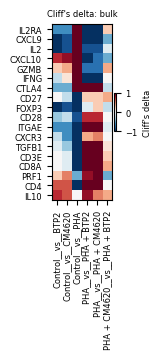

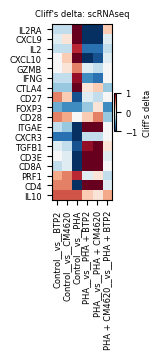

In [167]:
# ============================================
# Heatmaps for BOTH modalities with shared order
COMPARISON_ORDER = [f"{a}__vs__{b}" for (a,b) in COMPARISONS] 
# - rows   : hierarchical clustering from BULK, reused for SC
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

IN_DIR = Path("Outputs")
MASTER_CSV = IN_DIR / "trend_metrics_ALL.csv"
PREFERRED_METRIC = "cliffs_delta"
FALLBACK_METRIC = "cohens_d"

# Load master
df = pd.read_csv(MASTER_CSV)

# Choose metric column
metric_col = PREFERRED_METRIC if PREFERRED_METRIC in df.columns else None
if metric_col is None:
    if FALLBACK_METRIC in df.columns:
        warnings.warn(f"'{PREFERRED_METRIC}' not found; using '{FALLBACK_METRIC}' instead.")
        metric_col = FALLBACK_METRIC
    else:
        raise ValueError(f"Neither '{PREFERRED_METRIC}' nor '{FALLBACK_METRIC}' found in CSV.")

# Helper to build genes×comparisons matrix for a given modality
def make_mat(dfin, modality: str) -> pd.DataFrame:
    sub = dfin[dfin["modality"] == modality][["gene","cond_pair", metric_col]].drop_duplicates(["gene","cond_pair"])
    mat = sub.pivot(index="gene", columns="cond_pair", values=metric_col)
    # keep only comparisons in your specified order and present in this modality
    cols_present = [c for c in COMPARISON_ORDER if c in mat.columns]
    return mat.reindex(columns=cols_present).sort_index()

mat_bulk = make_mat(df, "bulk")
mat_sc   = make_mat(df, "sc")

# Use the intersection of columns so both heatmaps show the same comparisons
shared_cols = [c for c in COMPARISON_ORDER if (c in mat_bulk.columns and c in mat_sc.columns)]
mat_bulk = mat_bulk.reindex(columns=shared_cols)
mat_sc   = mat_sc.reindex(columns=shared_cols)

# -------- Row (gene) order from BULK clustering --------
# Cluster on correlation distance of rows in bulk
link = linkage(mat_bulk.fillna(0).values, method="average", metric="correlation")
row_order_idx = leaves_list(link)
bulk_gene_order = mat_bulk.index[row_order_idx]

# Reindex both matrices to the bulk-derived gene order
mat_bulk_ord = mat_bulk.reindex(index=bulk_gene_order)
mat_sc_ord   = mat_sc.reindex(index=bulk_gene_order)

# Mask invalids for clean imshow rendering (NaNs appear transparent)
bulk_array = np.ma.masked_invalid(mat_bulk_ord.values)
sc_array   = np.ma.masked_invalid(mat_sc_ord.values)

# -------- Plotting (faithful aesthetics) --------
vmin, vmax = -1, 1
fig_w, fig_h = 1.8, 3.7

for modality_name, arr, mat_ord in [
    ("bulk", bulk_array, mat_bulk_ord),
    ("scRNAseq", sc_array, mat_sc_ord),
]:
    plt.figure(figsize=(fig_w, fig_h))
    im = plt.imshow(arr, aspect="auto", interpolation="nearest",
                    cmap="RdBu_r", vmin=vmin, vmax=vmax)

    # ticks & labels with fontsize=6
    plt.xticks(range(mat_ord.shape[1]), mat_ord.columns, rotation=90, ha="center", fontsize=6)
    plt.yticks(range(mat_ord.shape[0]), mat_ord.index, fontsize=6)

    plt.grid(False)

    # colorbar with fontsize=6
    cbar = plt.colorbar(im, fraction=0.03, pad=0.02)
    label = "Cohen's d" if metric_col == "cohens_d" else "Cliff's delta"
    cbar.set_label(label, rotation=90, fontsize=6)
    cbar.ax.tick_params(labelsize=6)

    # title with fontsize=6
    plt.title(f"{label}: {modality_name}", fontsize=6)

    plt.tight_layout()
    plt.savefig(f'Figures/sc_vs_bulk/Cliff_{modality_name}_heatmap.pdf',
                bbox_inches='tight', dpi=300)
    plt.show()

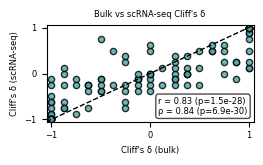

In [184]:
# =========================
# Scatter plot: Cliff's delta bulk vs sc
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Load merged data (bulk vs sc Cliff's delta)
df = pd.read_csv("Outputs/trend_metrics_ALL.csv")

if "cliffs_delta" not in df.columns:
    raise ValueError("No 'cliffs_delta' column found. Make sure you saved Cliff's delta in trend_metrics_ALL.csv.")

bulk = df[df["modality"]=="bulk"][["gene","cond_pair","cliffs_delta"]].rename(columns={"cliffs_delta":"bulk_delta"})
sc   = df[df["modality"]=="sc"][["gene","cond_pair","cliffs_delta"]].rename(columns={"cliffs_delta":"sc_delta"})
merged = pd.merge(bulk, sc, on=["gene","cond_pair"]).dropna(subset=["bulk_delta","sc_delta"])

X = merged["bulk_delta"].values
Y = merged["sc_delta"].values

# Correlations
pearson_r, pearson_p = pearsonr(X, Y)
spearman_r, spearman_p = spearmanr(X, Y)

# Plot
plt.figure(figsize=(2.75, 1.75))
plt.scatter(X, Y, s=20, alpha=0.8, edgecolor="k", color="#48A6A7")

# Reference line
lims = [min(X.min(), Y.min()) - 0.05, max(X.max(), Y.max()) + 0.05]
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims)
plt.ylim(lims)

# Labels and title with fontsize=6
plt.xlabel("Cliff's δ (bulk)", fontsize=6)
plt.ylabel("Cliff's δ (scRNA-seq)", fontsize=6)
plt.title("Bulk vs scRNA-seq Cliff's δ", fontsize=6)

# Correlation text (small font)
textstr = (f"r = {pearson_r:.2f} (p={pearson_p:.2g})\n"
           f"ρ = {spearman_r:.2f} (p={spearman_p:.2g})")
plt.gca().text(0.54, 0.06, textstr, transform=plt.gca().transAxes,
               fontsize=6, verticalalignment='bottom',
               bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Ticks font size
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.savefig("Figures/sc_vs_bulk/Cliff_corr.pdf", bbox_inches="tight", dpi=300)
plt.show()


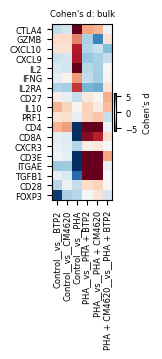

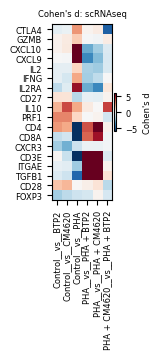

In [160]:
# ============================================
# Heatmaps for BOTH modalities with shared order
# - columns: COMPARISON_ORDER (present in both)
# - rows   : hierarchical clustering from BULK, reused for SC
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

IN_DIR = Path("Outputs")
MASTER_CSV = IN_DIR / "trend_metrics_ALL.csv"
PREFERRED_METRIC = "cohens_d"
FALLBACK_METRIC = "cliffs_delta"

# Load master
df = pd.read_csv(MASTER_CSV)

# Choose metric column
metric_col = PREFERRED_METRIC if PREFERRED_METRIC in df.columns else None
if metric_col is None:
    if FALLBACK_METRIC in df.columns:
        warnings.warn(f"'{PREFERRED_METRIC}' not found; using '{FALLBACK_METRIC}' instead.")
        metric_col = FALLBACK_METRIC
    else:
        raise ValueError(f"Neither '{PREFERRED_METRIC}' nor '{FALLBACK_METRIC}' found in CSV.")

# Helper to build genes×comparisons matrix for a given modality
def make_mat(dfin, modality: str) -> pd.DataFrame:
    sub = dfin[dfin["modality"] == modality][["gene","cond_pair", metric_col]].drop_duplicates(["gene","cond_pair"])
    mat = sub.pivot(index="gene", columns="cond_pair", values=metric_col)
    # keep only comparisons in your specified order and present in this modality
    cols_present = [c for c in COMPARISON_ORDER if c in mat.columns]
    return mat.reindex(columns=cols_present).sort_index()

mat_bulk = make_mat(df, "bulk")
mat_sc   = make_mat(df, "sc")

# Use the intersection of columns so both heatmaps show the same comparisons
shared_cols = [c for c in COMPARISON_ORDER if (c in mat_bulk.columns and c in mat_sc.columns)]
mat_bulk = mat_bulk.reindex(columns=shared_cols)
mat_sc   = mat_sc.reindex(columns=shared_cols)

# -------- Row (gene) order from BULK clustering --------
# Cluster on correlation distance of rows in bulk
link = linkage(mat_bulk.fillna(0).values, method="average", metric="correlation")
row_order_idx = leaves_list(link)
bulk_gene_order = mat_bulk.index[row_order_idx]

# Reindex both matrices to the bulk-derived gene order
mat_bulk_ord = mat_bulk.reindex(index=bulk_gene_order)
mat_sc_ord   = mat_sc.reindex(index=bulk_gene_order)

# Mask invalids for clean imshow rendering (NaNs appear transparent)
bulk_array = np.ma.masked_invalid(mat_bulk_ord.values)
sc_array   = np.ma.masked_invalid(mat_sc_ord.values)

# -------- Plotting (faithful aesthetics) --------
vmin, vmax = -6, 6
fig_w, fig_h = 1.8, 3.7

for modality_name, arr, mat_ord in [
    ("bulk", bulk_array, mat_bulk_ord),
    ("scRNAseq", sc_array, mat_sc_ord),
]:
    plt.figure(figsize=(fig_w, fig_h))
    im = plt.imshow(arr, aspect="auto", interpolation="nearest",
                    cmap="RdBu_r", vmin=vmin, vmax=vmax)

    # ticks & labels with fontsize=6
    plt.xticks(range(mat_ord.shape[1]), mat_ord.columns, rotation=90, ha="center", fontsize=6)
    plt.yticks(range(mat_ord.shape[0]), mat_ord.index, fontsize=6)

    plt.grid(False)

    # colorbar with fontsize=6
    cbar = plt.colorbar(im, fraction=0.03, pad=0.02)
    label = "Cohen's d" if metric_col == "cohens_d" else "Cliff's delta"
    cbar.set_label(label, rotation=90, fontsize=6)
    cbar.ax.tick_params(labelsize=6)

    # title with fontsize=6
    plt.title(f"{label}: {modality_name}", fontsize=6)

    plt.tight_layout()
    plt.savefig(f'Figures/sc_vs_bulk/Cohen_{modality_name}_heatmap.pdf',
                bbox_inches='tight', dpi=300)
    plt.show()

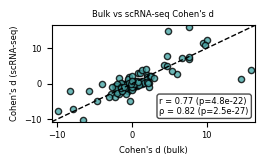

In [181]:
# =========================
# Scatter plot: Cohen's d bulk vs sc
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Load merged data (bulk vs sc Cohen's d)
df = pd.read_csv("Outputs/trend_metrics_ALL.csv")
bulk = df[df["modality"]=="bulk"][["gene","cond_pair","cohens_d"]].rename(columns={"cohens_d":"bulk_d"})
sc   = df[df["modality"]=="sc"][["gene","cond_pair","cohens_d"]].rename(columns={"cohens_d":"sc_d"})
merged = pd.merge(bulk, sc, on=["gene","cond_pair"]).dropna(subset=["bulk_d","sc_d"])

X = merged["bulk_d"].values
Y = merged["sc_d"].values

# Compute correlations
pearson_r, pearson_p = pearsonr(X, Y)
spearman_r, spearman_p = spearmanr(X, Y)

# Plot
plt.figure(figsize=(2.75, 1.75))
plt.scatter(X, Y, s=20, alpha=0.8, edgecolor="k", color="#48A6A7")

# Reference line
lims = [min(X.min(), Y.min()) - 0.5, max(X.max(), Y.max()) + 0.5]
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Cohen's d (bulk)", fontsize=6)
plt.ylabel("Cohen's d (scRNA-seq)", fontsize=6)
plt.title("Bulk vs scRNA-seq Cohen's d", fontsize=6)

# Correlation text (small font)
textstr = (f"r = {pearson_r:.2f} (p={pearson_p:.2g})\n"
           f"ρ = {spearman_r:.2f} (p={spearman_p:.2g})")
plt.gca().text(0.53, 0.06, textstr, transform=plt.gca().transAxes,
               fontsize=6, verticalalignment='bottom',
               bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Ticks font size
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.savefig(f'Figures/sc_vs_bulk/Cohen_corr.pdf', bbox_inches='tight', dpi=300)
plt.show()


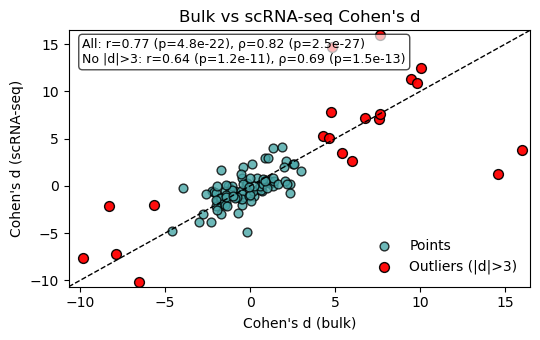

,gene,cond_pair,bulk_d,sc_d
17,FOXP3,Control__vs__BTP2,-5.651209,-2.020397
36,CD3E,Control__vs__PHA,-6.520628,-10.182190
37,CD4,Control__vs__PHA,-9.851500,-7.679791
38,CD8A,Control__vs__PHA,-7.906334,-7.194603
41,ITGAE,Control__vs__PHA,-8.310800,-2.120933
42,IL2,Control__vs__PHA,14.582773,1.294553
43,IL2RA,Control__vs__PHA,4.288546,5.223873
45,CXCL9,Control__vs__PHA,4.833938,14.748168
46,CXCL10,Control__vs__PHA,4.738012,7.866125
52,CTLA4,Control__vs__PHA,6.001196,2.651531


In [147]:
# =========================
# Scatter plot: Cohen's d bulk vs sc with outlier handling (|d|>3 on either axis)
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Load merged data (bulk vs sc Cohen's d)
df = pd.read_csv("Outputs/trend_metrics_ALL.csv")
bulk = df[df["modality"]=="bulk"][["gene","cond_pair","cohens_d"]].rename(columns={"cohens_d":"bulk_d"})
sc   = df[df["modality"]=="sc"][["gene","cond_pair","cohens_d"]].rename(columns={"cohens_d":"sc_d"})
merged = pd.merge(bulk, sc, on=["gene","cond_pair"]).dropna(subset=["bulk_d","sc_d"])

X = merged["bulk_d"].values
Y = merged["sc_d"].values

# Identify outliers: any point where |X| > 3 OR |Y| > 3
outlier_mask = (np.abs(X) > 5) | (np.abs(Y) > 5)
non_outlier_mask = ~outlier_mask

# Correlations on full set
pearson_r_all, pearson_p_all = pearsonr(X, Y)
spearman_r_all, spearman_p_all = spearmanr(X, Y)

# Correlations with outliers removed
if non_outlier_mask.sum() >= 3:  # need at least a few points
    X_no = X[non_outlier_mask]
    Y_no = Y[non_outlier_mask]
    pearson_r_no, pearson_p_no = pearsonr(X_no, Y_no)
    spearman_r_no, spearman_p_no = spearmanr(X_no, Y_no)
else:
    pearson_r_no = pearson_p_no = spearman_r_no = spearman_p_no = np.nan

# Plot
plt.figure(figsize=(5.5, 3.5))

# non-outliers
plt.scatter(
    X[non_outlier_mask], Y[non_outlier_mask],
    s=40, alpha=0.8, edgecolor="k", color="#48A6A7", label="Points"
)

# outliers (if any), shown in red
if outlier_mask.any():
    plt.scatter(
        X[outlier_mask], Y[outlier_mask],
        s=50, alpha=0.95, edgecolor="k", color="red", label="Outliers (|d|>3)"
    )

# Reference line
lims = [min(X.min(), Y.min()) - 0.5, max(X.max(), Y.max()) + 0.5]
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Cohen's d (bulk)")
plt.ylabel("Cohen's d (scRNA-seq)")
plt.title("Bulk vs scRNA-seq Cohen's d")

# Text box with both sets of metrics
textstr = (
    f"All: r={pearson_r_all:.2f} (p={pearson_p_all:.2g}), "
    f"ρ={spearman_r_all:.2f} (p={spearman_p_all:.2g})\n"
    f"No |d|>3: r={pearson_r_no:.2f} (p={pearson_p_no:.2g}), "
    f"ρ={spearman_r_no:.2f} (p={spearman_p_no:.2g})"
)
plt.gca().text(
    0.03, 0.97, textstr, transform=plt.gca().transAxes,
    fontsize=9, verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

if outlier_mask.any():
    plt.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

# Optional: inspect which points were outliers
if outlier_mask.any():
    display(merged.loc[outlier_mask, ["gene","cond_pair","bulk_d","sc_d"]])
